# 📒 Análisis de reportes de salud **sin Hadoop** (pandas + matplotlib)

Este notebook realiza un EDA (análisis exploratorio de datos) sobre `Datos_Simulados_Reportes.csv` usando **pandas** y **matplotlib**, sin MapReduce.

Incluye:
1. Carga del dataset (desde archivo local o subida manual).
2. Limpieza básica y normalización de columnas.
3. Gráficos: reportes por provincia, serie temporal diaria, distribución por género y edades.
4. Tabla de **picos por provincia** (día con mayor número de reportes por provincia).
5. Exportación del resumen de picos a CSV.

> Sube tu CSV si es necesario o ajusta la ruta de lectura.


In [3]:
# 1) Carga del dataset (intenta leer local; si no existe, pide subida)
import os # Importa el módulo os para interactuar con el sistema operativo
import pandas as pd # Importa la librería pandas para manipulación de datos y la renombra como pd
from pathlib import Path # Importa la clase Path del módulo pathlib para trabajar con rutas de archivos
csv_default = 'Datos_Simulados_Reportes.csv'  # Define el nombre por defecto del archivo CSV a cargar

if not Path(csv_default).exists(): # Comprueba si el archivo CSV por defecto no existe en la ruta actual
    try: # Intenta ejecutar el siguiente bloque de código
        from google.colab import files  # type: ignore # Intenta importar el módulo files de google.colab (solo disponible en Google Colab)
        print('Sube tu archivo CSV (p. ej., Datos_Simulados_Reportes.csv)') # Imprime un mensaje solicitando al usuario que suba el archivo
        uploaded = files.upload() # Abre una ventana para que el usuario suba un archivo y guarda el resultado en la variable uploaded
        csv_default = list(uploaded.keys())[0] # Obtiene el nombre del archivo subido (la primera clave del diccionario uploaded)
    except Exception: # Si ocurre una excepción en el bloque try (por ejemplo, si no está en Colab)
        # Si no estás en Colab, puedes colocar el CSV en el mismo directorio del notebook.
        pass # No hace nada, simplemente ignora el error (asumiendo que el archivo se colocará manualmente)

df = pd.read_csv(csv_default) # Carga el archivo CSV (ya sea el por defecto o el subido) en un DataFrame de pandas
print('Filas x Columnas:', df.shape) # Imprime el número de filas y columnas del DataFrame
df.head(3) # Muestra las primeras 3 filas del DataFrame

Filas x Columnas: (50000, 6)


,fecha,sintoma,provincia,genero,edad,fecha_dia
0,2025-12-06 00:30:00,tos,San José,F,1,2025-12-06
1,2026-04-20 16:45:00,dolor de cabeza,Puntarenas,F,81,2026-04-20
2,2025-08-02 06:15:00,dolor de cabeza,Limón,M,47,2025-08-02


In [4]:
# 2) Limpieza básica y normalización de columnas
import numpy as np # Importa la librería numpy para operaciones numéricas (aunque no se usa directamente en este snippet)

df.columns = [c.strip() for c in df.columns] # Elimina espacios en blanco al inicio y al final de los nombres de las columnas
lower = {c.lower(): c for c in df.columns} # Crea un diccionario donde las claves son los nombres de las columnas en minúsculas y los valores son los nombres originales

col_fecha = next((lower[k] for k in lower if 'fecha' in k), None) # Busca una columna cuyo nombre (en minúsculas) contenga 'fecha' y guarda su nombre original; si no la encuentra, guarda None
col_prov = next((lower[k] for k in lower if 'provincia' in k), None) # Busca una columna cuyo nombre (en minúsculas) contenga 'provincia' y guarda su nombre original; si no la encuentra, guarda None
col_genero = next((lower[k] for k in lower if ('genero' in k or 'género' in k or 'sexo' in k)), None) # Busca una columna cuyo nombre (en minúsculas) contenga 'genero', 'género' o 'sexo' y guarda su nombre original; si no la encuentra, guarda None
col_edad = next((lower[k] for k in lower if 'edad' in k), None) # Busca una columna cuyo nombre (en minúsculas) contenga 'edad' y guarda su nombre original; si no la encuentra, guarda None

if col_prov is not None: # Comprueba si se encontró la columna de provincia
    df[col_prov] = df[col_prov].astype(str).str.strip().str.title() # Convierte la columna de provincia a tipo string, elimina espacios, capitaliza la primera letra de cada palabra
    df[col_prov] = df[col_prov].str.replace('Limon', 'Limón').str.replace('San Jose', 'San José') # Reemplaza 'Limon' por 'Limón' y 'San Jose' por 'San José' en la columna de provincia

if col_fecha is not None: # Comprueba si se encontró la columna de fecha
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce') # Convierte la columna de fecha a formato datetime, forzando los errores a NaT (Not a Time)
    df['dia'] = df[col_fecha].dt.date # Extrae solo la parte de la fecha (sin la hora) de la columna de fecha y la guarda en una nueva columna llamada 'dia'

df.head(3) # Muestra las primeras 3 filas del DataFrame actualizado

,fecha,sintoma,provincia,genero,edad,fecha_dia,dia
0,2025-12-06 00:30:00,tos,San José,F,1,2025-12-06,2025-12-06
1,2026-04-20 16:45:00,dolor de cabeza,Puntarenas,F,81,2026-04-20,2026-04-20
2,2025-08-02 06:15:00,dolor de cabeza,Limón,M,47,2025-08-02,2025-08-02


## 3) Visualizaciones con matplotlib

> Nota: evitamos estilos o colores específicos para mantener el enfoque básico de `matplotlib`.

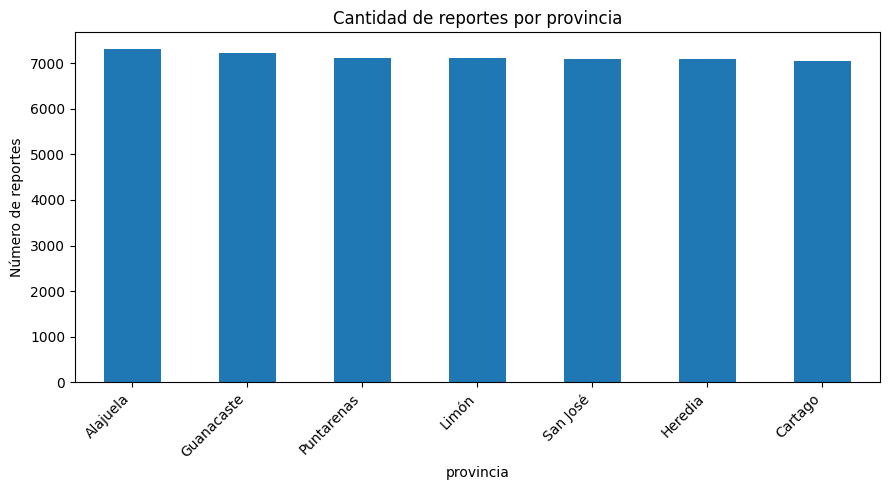

In [5]:
# 3.1 Reportes por provincia
import matplotlib.pyplot as plt # Importa la librería matplotlib.pyplot para crear gráficos y la renombra como plt

if col_prov is not None: # Comprueba si se encontró la columna de provincia
    prov_counts = df[col_prov].value_counts().sort_values(ascending=False) # Cuenta la frecuencia de cada valor único en la columna de provincia y los ordena de forma descendente
    plt.figure(figsize=(9,5)) # Crea una nueva figura para el gráfico con un tamaño específico
    prov_counts.plot(kind='bar') # Crea un gráfico de barras a partir de los conteos por provincia
    plt.title('Cantidad de reportes por provincia') # Establece el título del gráfico
    plt.ylabel('Número de reportes') # Establece la etiqueta del eje Y
    plt.xticks(rotation=45, ha='right') # Rota las etiquetas del eje X 45 grados para mejor legibilidad
    plt.tight_layout() # Ajusta automáticamente los parámetros de la figura para que el diseño sea compacto
    plt.show() # Muestra el gráfico
else: # Si no se encontró la columna de provincia
    print('No se encontró la columna de provincia.') # Imprime un mensaje indicando que no se encontró la columna

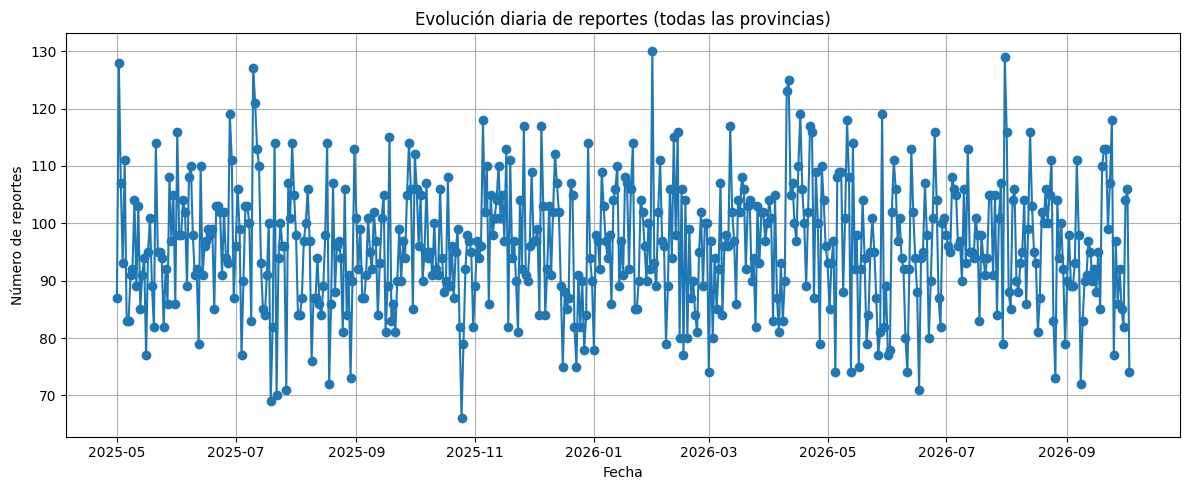

In [6]:
# 3.2 Evolución diaria de reportes (todas las provincias)
import matplotlib.pyplot as plt # Importa la librería matplotlib.pyplot para crear gráficos y la renombra como plt

if 'dia' in df.columns: # Comprueba si la columna 'dia' existe en el DataFrame
    daily_counts = df.groupby('dia').size() # Agrupa el DataFrame por la columna 'dia' y cuenta el número de filas en cada grupo (reportes por día)
    plt.figure(figsize=(12,5)) # Crea una nueva figura para el gráfico con un tamaño específico
    plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-') # Crea un gráfico de línea con los días en el eje X y el número de reportes en el eje Y
    plt.title('Evolución diaria de reportes (todas las provincias)') # Establece el título del gráfico
    plt.ylabel('Número de reportes') # Establece la etiqueta del eje Y
    plt.xlabel('Fecha') # Establece la etiqueta del eje X
    plt.grid(True) # Muestra una cuadrícula en el gráfico
    plt.tight_layout() # Ajusta automáticamente los parámetros de la figura para que el diseño sea compacto
    plt.show() # Muestra el gráfico
else: # Si la columna 'dia' no existe
    print('No se pudo construir la serie diaria (revisa la columna de fecha).') # Imprime un mensaje indicando que no se pudo construir la serie diaria

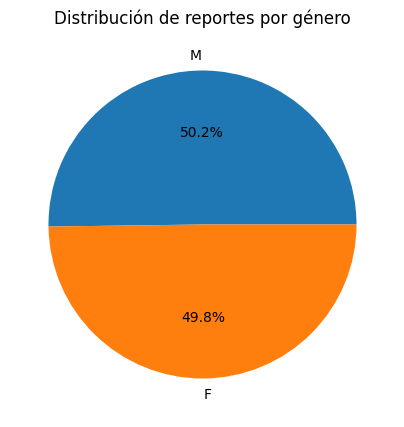

In [9]:
# 3.3 Distribución por género (si existe)
import matplotlib.pyplot as plt # Importa la librería matplotlib.pyplot para crear gráficos y la renombra como plt

if col_genero is not None: # Comprueba si se encontró la columna de género/sexo
    genero_counts = df[col_genero].astype(str).str.strip().str.title().value_counts() # Cuenta la frecuencia de cada valor único en la columna de género (convirtiendo a string, eliminando espacios y capitalizando)
    plt.figure(figsize=(5,5)) # Crea una nueva figura para el gráfico con un tamaño específico (usualmente cuadrado para gráficos de pastel)
    plt.pie(genero_counts.values, labels=genero_counts.index, autopct='%1.1f%%') # Crea un gráfico de pastel con los conteos como valores, los nombres de los géneros como etiquetas y muestra el porcentaje de cada sección
    plt.title('Distribución de reportes por género') # Establece el título del gráfico
    plt.show() # Muestra el gráfico
else: # Si no se encontró la columna de género/sexo
    print('No se encontró la columna de género/sexo.') # Imprime un mensaje indicando que no se encontró la columna

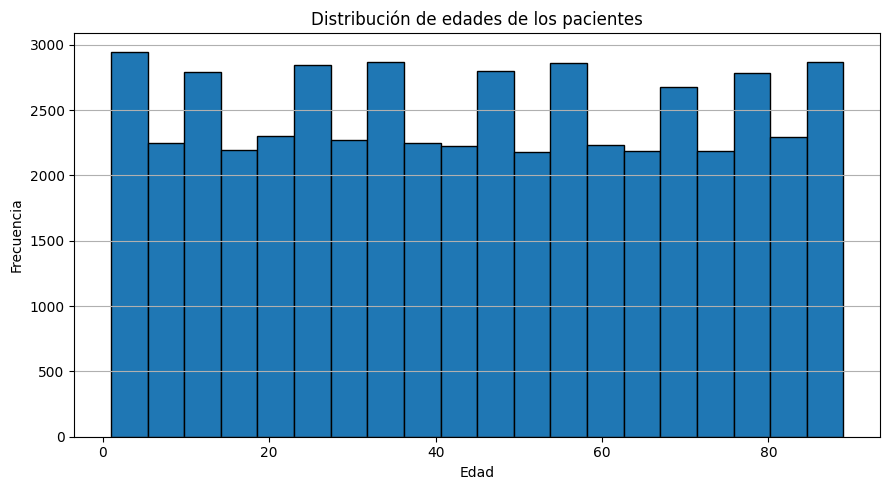

In [10]:
# 3.4 Histograma de edades (si existe)
import matplotlib.pyplot as plt # Importa la librería matplotlib.pyplot para crear gráficos y la renombra como plt

if col_edad is not None: # Comprueba si se encontró la columna de edad
    plt.figure(figsize=(9,5)) # Crea una nueva figura para el gráfico con un tamaño específico
    df[col_edad].dropna().astype(float).plot(kind='hist', bins=20, edgecolor='black') # Elimina los valores nulos de la columna de edad, la convierte a tipo float, y crea un histograma con 20 barras y bordes negros
    plt.title('Distribución de edades de los pacientes') # Establece el título del gráfico
    plt.xlabel('Edad') # Establece la etiqueta del eje X
    plt.ylabel('Frecuencia') # Establece la etiqueta del eje Y
    plt.grid(axis='y') # Muestra una cuadrícula solo en el eje Y
    plt.tight_layout() # Ajusta automáticamente los parámetros de la figura para que el diseño sea compacto
    plt.show() # Muestra el gráfico
else: # Si no se encontró la columna de edad
    print('No se encontró la columna de edad.') # Imprime un mensaje indicando que no se encontró la columna

## 4) Picos por provincia (día con mayor número de reportes)
Calculamos, para cada provincia, cuál fue el **día con más reportes** y cuántos hubo.

In [12]:
# 4) Picos por provincia (día con mayor número de reportes)
from IPython.display import display # Importa la función display para mostrar DataFrames de forma amigable
import pandas as pd # Importa la librería pandas (aunque ya estaba importada, se incluye por si la celda se ejecuta sola)

# Comprueba si las columnas de provincia y 'dia' existen en el DataFrame
if (col_prov is not None) and ('dia' in df.columns):
    # Agrupa el DataFrame por provincia y día, cuenta el número de reportes en cada grupo y renombra la columna resultante a 'reportes'
    summary = df.groupby([col_prov, 'dia']).size().reset_index(name='reportes')
    # Ordena el resumen por el número de reportes de forma descendente y luego selecciona la primera fila para cada provincia (el día con más reportes)
    summary_picos = summary.sort_values(['reportes'], ascending=False).groupby(col_prov).head(1)
    # Muestra la tabla de picos por provincia
    display(summary_picos)
else:
    # Si no se encontraron las columnas necesarias, imprime un mensaje
    print('Faltan columnas para construir la tabla de picos (provincia y/o fecha).')

,provincia,dia,reportes
2334,Limón,2026-01-06,27
2884,Puntarenas,2026-02-04,26
213,Alajuela,2025-11-30,26
3514,San José,2026-05-24,25
1307,Guanacaste,2026-01-21,25
977,Cartago,2026-07-31,24
1772,Heredia,2025-11-26,23


In [14]:
# 5) Exportación a CSV (picos por provincia)
# Comprueba si la variable 'summary_picos' existe en el ámbito local (es decir, si se creó la tabla de picos)
if 'summary_picos' in locals():
    out_csv = 'picos_por_provincia_sin_hadoop.csv' # Define el nombre del archivo CSV de salida
    summary_picos.to_csv(out_csv, index=False) # Exporta la tabla de picos a un archivo CSV, sin incluir el índice del DataFrame
    print('CSV exportado:', out_csv) # Imprime un mensaje indicando el nombre del archivo exportado
    try: # Intenta ejecutar el siguiente bloque de código
        from google.colab import files  # type: ignore # Intenta importar el módulo files de google.colab para descargar el archivo
        files.download(out_csv) # Descarga el archivo CSV al sistema local del usuario
    except Exception: # Si ocurre una excepción (por ejemplo, no está en Colab)
        pass # No hace nada, simplemente ignora el error
else:
    # Si la variable 'summary_picos' no existe, imprime un mensaje indicando que no hay tabla para exportar
    print('No hay tabla de picos para exportar.')

CSV exportado: picos_por_provincia_sin_hadoop.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>